<a href="https://colab.research.google.com/github/Viboth712/BUSA-8000-Nouviboth-RA/blob/main/Default_Credit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
# pd.set_option("display.max_rows", None, "display.max_columns", None, "display.width", None) # pretty printing

df = pd.read_excel('https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls', skiprows=[0])

In [3]:
df.to_excel('credit_card_defaults.xlsx')

In [4]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
df.info(b)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [6]:
df = df.rename(columns={'PAY_0': 'PAY_1', 'default payment next month': 'payment_default'})

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_1,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [8]:
y = df['payment_default'].loc[:99].values
X = df[['PAY_1', 'AGE']].loc[:99].values

print(y, y.shape)
print(X, X.shape)

[1 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 1 1 0 0 1 0 0 0 0 1 0 0 0 0 0
 0 1 0 0 0 0 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 1 0 0 0 0 1 0 0
 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 1] (100,)
[[ 2 24]
 [-1 26]
 [ 0 34]
 [ 0 37]
 [-1 57]
 [ 0 37]
 [ 0 29]
 [ 0 23]
 [ 0 28]
 [-2 35]
 [ 0 34]
 [-1 51]
 [-1 41]
 [ 1 30]
 [ 0 29]
 [ 1 23]
 [ 0 24]
 [ 0 49]
 [ 1 49]
 [ 1 29]
 [ 0 39]
 [-1 39]
 [ 2 26]
 [-2 40]
 [ 0 23]
 [ 0 23]
 [ 1 27]
 [ 0 30]
 [-1 47]
 [ 0 26]
 [-1 27]
 [ 2 33]
 [ 0 32]
 [-2 54]
 [-2 58]
 [-1 30]
 [ 0 40]
 [ 0 22]
 [ 1 25]
 [-1 31]
 [ 0 33]
 [ 0 25]
 [ 0 22]
 [ 0 37]
 [ 0 30]
 [-2 29]
 [ 0 22]
 [ 0 46]
 [-1 32]
 [ 0 24]
 [ 1 42]
 [ 0 43]
 [-2 49]
 [ 1 25]
 [ 2 29]
 [-2 45]
 [ 0 34]
 [ 0 34]
 [-1 34]
 [ 0 29]
 [ 0 28]
 [ 0 39]
 [ 2 29]
 [ 0 46]
 [-1 51]
 [-2 57]
 [ 2 56]
 [ 2 30]
 [ 1 29]
 [ 2 22]
 [-1 31]
 [ 2 29]
 [-1 32]
 [ 1 37]
 [-1 32]
 [ 0 24]
 [-1 25]
 [-1 45]
 [ 0 22]
 [ 1 44]
 [ 0 33]
 [ 0 26]
 [ 0 30]
 [ 0 44]
 [ 0 49]
 [ 0 33]
 [-1 45]
 [ 0 3

In [9]:
import numpy as np
np.set_printoptions(precision=3, suppress = True)       # format printing to 3 decimal places in numpy


pd.options.display.float_format = '{:,.3f}'.format      # format printing to 3 decimal places in pandas
X_stand = (X - X.mean(axis=0)) / X.std(axis=0)

print('Means:', X_stand.mean(axis=0))
print('Standard Deviations:', X_stand.std(axis=0))

Means: [0. 0.]
Standard Deviations: [1. 1.]


In [13]:
import sys
import numpy as np

class Perceptron:
    ''' Perceptron classifier

    Parameters:
    ----------
    eta: learning Rate between 0.0 and 1.0
    n_iter: to go over the training set
    random_state: random number generator seed for random weight initialisation


    Attributes:
    -----------
    w_ : weights after fitting
    errors_ number of misclassifications in each epoch
    '''

    def __init__(self, eta=0.01, n_iter=10, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        ''' Fit training data

        Paramters:
        ----------
        X: shape = [number_examples, number_features] - training data
        y: shape = [number_examples] - target values

        Returns:
        --------
        self: object
        '''

        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])  # scale is standard deviation
        self.errors_ = []

        for _ in range(self.n_iter):
            print(f'---------------- Epoch:{_} -----------------')
            errors = 0
            for i, (xi, target) in enumerate(zip(X, y)): # for each row in zip(X,y)
                update = self.eta * (target - self.predict(xi)) # for each row xi
                errors += int(update != 0)
             #   print(f'observation: {i}, x: {xi}, w: {self.w_} y: {target}, prediction: {self.predict(xi)}, update factor: {update}, errors: {errors}')
                self.w_[1:] = self.w_[1:] + update*xi
                self.w_[0] = self.w_[0] + update
            self.errors_.append(errors)
        print(len(self.errors_))

        return self

    def net_input(self, X):   # X is a row of X
        ''' Calculate net input '''
        return np.dot(X, self.w_[1:]) + self.w_[0]  # np.dot function computes the vector dot (inner) product w'x

    def predict(self, X):  # X is a row of X
        ''' Return class label after unit step '''
        # return np.where(self.net_input(X) >= 0, 1, -1)
        return np.where(self.net_input(X) >= 0, 1, 0)

    def print_weights(self):
        print(f'Optimized weights: {self.w_}')

In [14]:
import Perceptron as prc
import matplotlib.pyplot as plt
import numpy as np

In [15]:
ppn = prc.Perceptron(eta=0.001, n_iter=10, random_state = 1)
ppn.fit(X_stand, y)
ppn.predict(X_stand)

---------------- Epoch:0 -----------------
---------------- Epoch:1 -----------------
---------------- Epoch:2 -----------------
---------------- Epoch:3 -----------------
---------------- Epoch:4 -----------------
---------------- Epoch:5 -----------------
---------------- Epoch:6 -----------------
---------------- Epoch:7 -----------------
---------------- Epoch:8 -----------------
---------------- Epoch:9 -----------------
10


array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [16]:
true_predicted_errors = pd.DataFrame(np.array([y, ppn.predict(X_stand)]).T, columns=['True', 'Predicted'])
true_predicted_errors['Errors'] = abs(true_predicted_errors['True'] - true_predicted_errors['Predicted'])
print(true_predicted_errors.mean())
print('accuracy =',100*(1-true_predicted_errors.mean()[2]), 'percent')

True        0.260
Predicted   0.250
Errors      0.270
dtype: float64
accuracy = 73.0 percent


/tmp/ipykernel_2296/2920348383.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print('accuracy =',100*(1-true_predicted_errors.mean()[2]), 'percent')


In [17]:
from matplotlib.colors import ListedColormap
def plot_decision_regions(X, y, classifier, resolution=0.02):
    # setup marker generator and color map
    markers = ['s', 'x', 'o', '^', 'v']
    colors = ['red', 'blue', 'lightgreen', 'gray', 'cyan']
    cmap = ListedColormap(colors[:len(np.unique(y))])

    #plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution), np.arange(x2_min, x2_max, resolution))
#     print(xx1.shape)
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
#     print(np.array([xx1.ravel(), xx2.ravel()]).T.shape)
    Z = Z.reshape(xx1.shape)
#     print(Z.shape)

    plt.contourf(xx1, xx2, Z, alpha = 0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    #plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha = 0.8, c = colors[idx], marker = markers[idx], label = cl, edgecolor = 'black')

/tmp/ipykernel_2296/3805657181.py:24: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha = 0.8, c = colors[idx], marker = markers[idx], label = cl, edgecolor = 'black')


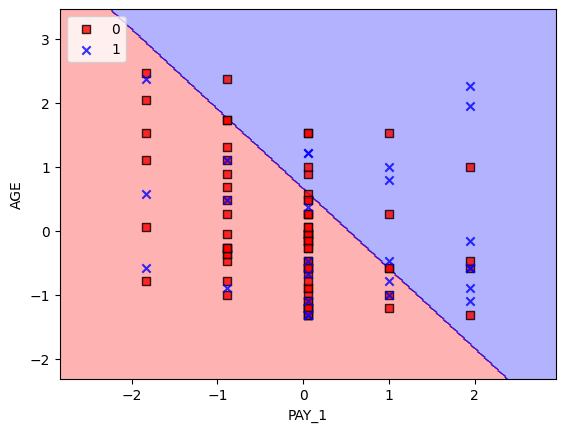

In [18]:
plot_decision_regions(X_stand, y, classifier=ppn)
plt.xlabel('PAY_1')
plt.ylabel('AGE')
plt.legend(loc='upper left')

plt.show()